# Universal Approximation Theorem

Universal Approximation Theorem이란 1개의 비선형 Activation함수를 포함하고 있는 히든 레이어를 가진 Neural Network를 이용해 어떠한 함수든 근사시킬 수 있다는 이론.
universal approximation Theorm

In [11]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

In [12]:
def func(x):
    """
    근사시키려는 함수
    """
    return 7*np.sin(x)*np.cos(x)*(2*x**2+5*x**3+x**2)*np.tan(x)+120 

In [13]:
x = np.linspace(-10, 10, 100)
y = func(x)

In [14]:
x
y

array([-9.61705008e+03, -3.98831643e+03, -7.21318592e+02,  9.41775339e+01,
       -1.23298184e+03, -4.09229365e+03, -7.70728865e+03, -1.12827929e+04,
       -1.41376494e+04, -1.58022191e+04, -1.60683775e+04, -1.49893127e+04,
       -1.28353912e+04, -1.00191958e+04, -7.00657752e+03, -4.23088831e+03,
       -2.02481714e+03, -5.79277382e+02,  6.72403804e+01,  1.13162728e+01,
       -5.53613164e+02, -1.38643734e+03, -2.24805212e+03, -2.94250151e+03,
       -3.34345618e+03, -3.40355195e+03, -3.14770160e+03, -2.65434563e+03,
       -2.03027132e+03, -1.38494559e+03, -8.09405447e+02, -3.62985074e+02,
       -6.90151843e+01,  8.13972792e+01,  1.19908210e+02,  8.89413862e+01,
        3.02517980e+01, -2.35820235e+01, -5.34898569e+01, -5.40276488e+01,
       -3.02436574e+01,  7.15640230e+00,  4.66959860e+01,  7.97565044e+01,
        1.02262163e+02,  1.14435029e+02,  1.19209378e+02,  1.20198452e+02,
        1.20084994e+02,  1.20001812e+02,  1.20002546e+02,  1.20258452e+02,
        1.22309640e+02,  

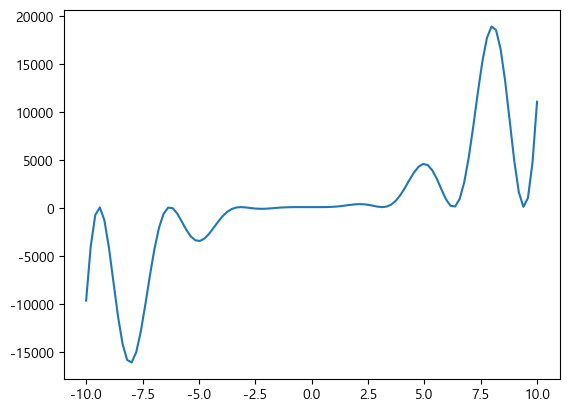

In [15]:
plt.plot(x, y)
plt.show()

In [16]:
X_train = torch.tensor(x, dtype=torch.float32).unsqueeze(dim=1).to(device)
y_train = torch.tensor(y, dtype=torch.float32).unsqueeze(dim=1).to(device)

X_train.shape, y_train.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

In [18]:
# 모델
model = nn.Sequential(
    nn.Linear(1, 10000), # 10000은 임의로 지정 어떤 값을 특성을 10000개로 확대
    # nn.ReLU(),
    nn.Sigmoid(),
    nn.Linear(10000, 1) # 10000개를 1개로 출력
).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01)

In [21]:
# 학습
model.train()
for epoch in range(5000):
    # 추론
    pred = model(X_train)
    # 오차
    loss = loss_fn(pred, y_train)
    # grandient
    loss.backward()
    # 파라미터 업데이트
    optimizer.step()
    # 파라미터 초기화
    optimizer.zero_grad()
print("완료")

완료


In [22]:
y_pred = model(X_train)

In [23]:
# y_pred값을 ndarray로 변환
## 1. device를 cpu로 이동.
## 2. grad_fn 있는 경우 제거.
y_pred_array = y_pred.to("cpu").detach().numpy().flatten()

In [24]:
y_pred_array.shape

(100,)

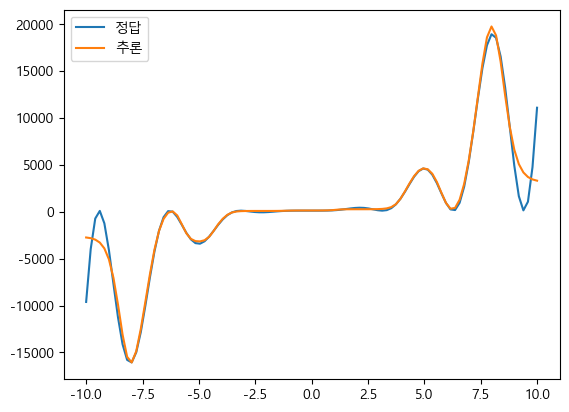

In [25]:
plt.plot(x, y, label="정답")
plt.plot(x, y_pred_array, label="추론")
plt.legend()
plt.show()

layer가 단순할 때 sigmoid 활성화 함수가 잘 맞는다.